### DATA INGESTION 

**INITIALIZE SPARKNLP AND OTHER PACKAGES**

In [19]:
# =========================
# Standard Library
# =========================
import os
import json
from itertools import chain

# =========================
# Numerical & Data Handling
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Spark & Spark NLP
# =========================
# =========================
# Spark & Spark NLP
# =========================
import sparknlp
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, lit, udf, when, array_max, create_map, desc, expr
from pyspark.sql.types import FloatType


from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import (
    CountVectorizer,
    IDF,
    NGram,
    VectorAssembler,
    StringIndexer,
    StringIndexerModel
)
from pyspark.ml.classification import LogisticRegression, LogisticRegressionModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

from sparknlp.base import DocumentAssembler, EmbeddingsFinisher, Finisher
from sparknlp.annotator import (
    Tokenizer,
    Normalizer,
    Stemmer,
    StopWordsCleaner,
    BertEmbeddings,
    BertSentenceEmbeddings,
    SentenceEmbeddings,
    ClassifierDLApproach
)

# =========================
# Scikit-learn Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# =========================
# MLflow
# =========================
import mlflow
import mlflow.spark


In [20]:
# Environment Configuration
# ----------------------------
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"  # ensures Spark binds to localhost

# 1. Point MLflow to your local folder (mlruns is one level up from notebooks/)
mlflow.set_tracking_uri("file:../mlruns")

# 2. Create or reuse an experiment called "legal_doc_classification"
mlflow.set_experiment("CONTRACT_NLP_CLASSIFICATION")


<Experiment: artifact_location='file:///Users/jefferyjapheth/Documents/dev/devsuite/project/contract_nlp/notebooks/../mlruns/311994224632715344', creation_time=1756997161474, experiment_id='311994224632715344', last_update_time=1756997161474, lifecycle_stage='active', name='CONTRACT_NLP_CLASSIFICATION', tags={}>

**START SPARK SESSION FOR SPARKNLP**

In [21]:
spark = (SparkSession.builder
    .appName("Text_Classification_NLP")
    .master("local[8]")
    .config("spark.driver.memory", "12g")
    .config("spark.executor.memory", "12g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    # Use direct JAR for Apple Silicon - version 6.1.2
    .config("spark.jars", "../misc/spark-nlp-silicon-assembly-6.1.2.jar")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "2000M")
    # Apple Silicon optimizations
    .config("spark.driver.extraJavaOptions", "-XX:+UseG1GC")
    .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC")
     # Tell Spark NLP where to cache / look for pretrained models
    .config("spark.jsl.settings.pretrained.cache_folder", "./models")
    .getOrCreate()
)

# Check if SparkNLP is loaded
print("Spark version:", spark.version)
print("SparkNLP version:", sparknlp.version())

# Test that it's working
from sparknlp.pretrained import PretrainedPipeline
print("SparkNLP initialized successfully with Apple Silicon support")

Spark version: 3.5.6
SparkNLP version: 6.1.2
SparkNLP initialized successfully with Apple Silicon support


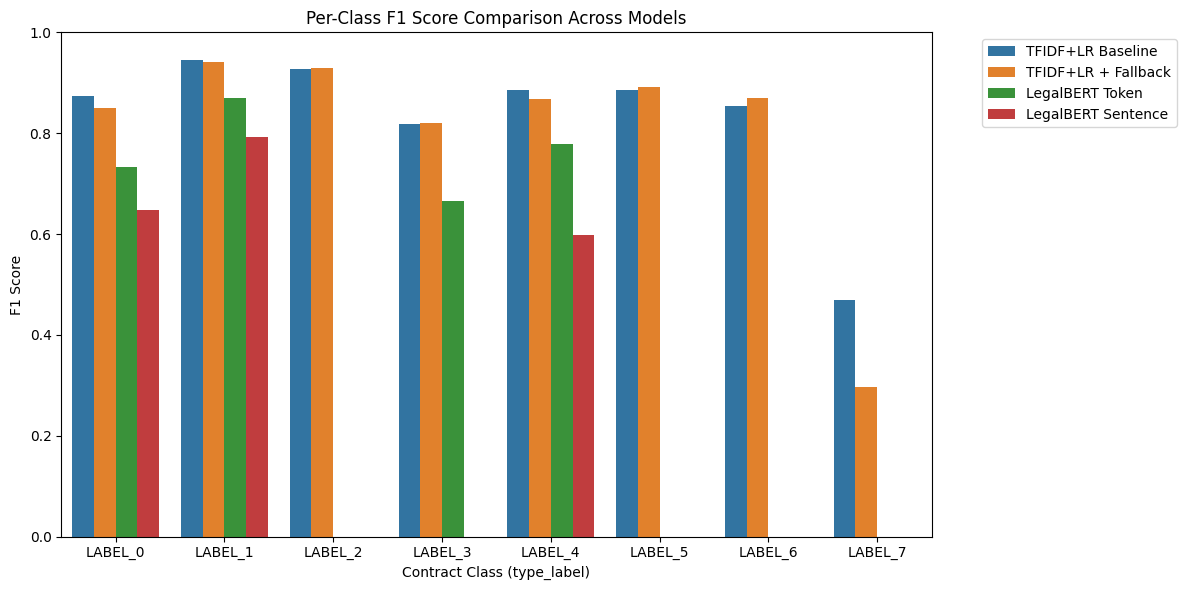

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels
labels = ["LABEL_0","LABEL_1","LABEL_2","LABEL_3","LABEL_4","LABEL_5","LABEL_6","LABEL_7"]

# F1 scores per model (from your classification reports)
f1_baseline = [0.874, 0.945, 0.928, 0.819, 0.885, 0.886, 0.854, 0.470]
f1_fallback = [0.850, 0.942, 0.929, 0.821, 0.868, 0.891, 0.869, 0.297]
f1_legalbert_token = [0.733, 0.869, 0.0, 0.666, 0.778, 0.0, 0.0, 0.0]
f1_legalbert_sentence = [0.647, 0.793, 0.0, 0.0, 0.599, 0.0, 0.0, 0.0]

# Create dataframe
df_plot = pd.DataFrame({
    "Class": labels,
    "TFIDF+LR Baseline": f1_baseline,
    "TFIDF+LR + Fallback": f1_fallback,
    "LegalBERT Token": f1_legalbert_token,
    "LegalBERT Sentence": f1_legalbert_sentence
})

# Melt for seaborn
df_melt = df_plot.melt(id_vars="Class", var_name="Model", value_name="F1_score")

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x="Class", y="F1_score", hue="Model")
plt.title("Per-Class F1 Score Comparison Across Models")
plt.ylabel("F1 Score")
plt.xlabel("Contract Class (type_label)")
plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**LOAD CLEAN MCC DATASET**

In [4]:
# Load the cleaned contract dataset
df = spark.read.parquet("../data/processed/mcc_contracts_full")

print(f"Dataset loaded! Total records: {df.count():,}")
df.printSchema()

Dataset loaded! Total records: 396,532
root
 |-- company_name: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- description: string (nullable = true)
 |-- amend: string (nullable = true)
 |-- restate: string (nullable = true)
 |-- joinder: double (nullable = true)
 |-- termination: integer (nullable = true)
 |-- agreement_type: string (nullable = true)
 |-- data_split: integer (nullable = true)
 |-- label_count: long (nullable = true)
 |-- type_label: string (nullable = true)



### DATA EXPLORATION TO SHOW CLASS DISTRIBUTION/ DATA SPLITS AND SAMPLE RECORDS

In [5]:
#Data Exploration and Basic Stats

# Show class distribution
print("Class Distribution:")
df.groupBy("agreement_type", "type_label").count().orderBy(desc("count")).show()

# Check data splits
print("Data Split Distribution:")
df.groupBy("data_split").count().show()

# Sample records to see the text
print("Sample Records:")
df.select("contract", "description", "agreement_type").limit(3).show(truncate=False)

Class Distribution:


+---------------+----------+------+
| agreement_type|type_label| count|
+---------------+----------+------+
|     employment|   LABEL_1|144783|
|       security|   LABEL_0|102425|
|    purchase&ma|   LABEL_4| 56612|
|services&supply|   LABEL_3| 32168|
|    shareholder|   LABEL_5| 20002|
|          other|   LABEL_6| 18203|
|          lease|   LABEL_2| 11879|
|             na|   LABEL_7| 10460|
+---------------+----------+------+

Data Split Distribution:
+----------+-----+
|data_split|count|
+----------+-----+
|         1|79007|
|         2|79373|
|         3|79461|
|         4|79260|
|         5|79431|
+----------+-----+

Sample Records:
+---------------------------------------------------------------------+------------------------------------------+--------------+
|contract                                                             |description                               |agreement_type|
+---------------------------------------------------------------------+-----------------------

**DOWNSAMPLING AND COMPUTING CLASS WEIGHTS TO TACKLE CLASS IMBALANCE**

In [6]:
#  Identify majority classes to downsample
# ----------------------------
majority_classes = ["employment", "security"]

# Define downsample fractions (reduce to 50% of their current counts)
downsample_fractions = {
    "employment": 0.5,
    "security": 0.5
}

# For classes not in majority_classes, keep all
all_labels = [row["agreement_type"] for row in df.select("agreement_type").distinct().collect()]
for label in all_labels:
    if label not in majority_classes:
        downsample_fractions[label] = 1.0


#  Downsample dataset
# ----------------------------
df_downsampled = df.sampleBy("agreement_type", fractions=downsample_fractions, seed=42)
print(f"Original count: {df.count():,}, After downsampling: {df_downsampled.count():,}")

# check new class distribution
print("Downsampled Class Distribution:")
df_downsampled.groupBy("agreement_type", "type_label").count().orderBy(desc("count")).show()

Original count: 396,532, After downsampling: 273,127
Downsampled Class Distribution:
+---------------+----------+-----+
| agreement_type|type_label|count|
+---------------+----------+-----+
|     employment|   LABEL_1|72546|
|    purchase&ma|   LABEL_4|56612|
|       security|   LABEL_0|51257|
|services&supply|   LABEL_3|32168|
|    shareholder|   LABEL_5|20002|
|          other|   LABEL_6|18203|
|          lease|   LABEL_2|11879|
|             na|   LABEL_7|10460|
+---------------+----------+-----+



In [7]:
# Compute counts per class
label_counts = df_downsampled.groupBy("type_label").count().collect()
total_count = df_downsampled.count()
num_classes = len(label_counts)

# Compute class weights = total_count / (num_classes * count)
class_weights = {row['type_label']: total_count / (num_classes * row['count']) for row in label_counts}

# UDF to assign weight to each row
def get_weight(label):
    return float(class_weights[label])

weight_udf = udf(get_weight, FloatType())
df_weighted = df_downsampled.withColumn("class_weight", weight_udf(F.col("type_label")))

df = df_weighted
# Quick check
df.groupBy("type_label").agg(F.avg("class_weight")).show()

+----------+-------------------+
|type_label|  avg(class_weight)|
+----------+-------------------+
|   LABEL_0|  0.666072428226471|
|   LABEL_4| 0.6030678153038025|
|   LABEL_1|0.47061002254486084|
|   LABEL_5| 1.7068730592727661|
|   LABEL_3| 1.0613303184509277|
|   LABEL_7|  3.263946056365967|
|   LABEL_2| 2.8740530014038086|
|   LABEL_6|  1.875563144683838|
+----------+-------------------+



## Text preprocessing in Spark NLP and using ML algorithms from Spark ML

### NLP PIPELINE FOR CLASSICAL ML MODELS

In [8]:
# Document
document_assembler = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# Tokenize
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("tokens")

# Normalize
normalizer = Normalizer() \
    .setInputCols(["tokens"]) \
    .setOutputCol("normalized_tokens") \
    .setLowercase(True)

# Stemmer (better for TF-IDF classification)
stemmer = Stemmer() \
    .setInputCols(["normalized_tokens"]) \
    .setOutputCol("stem_tokens")

# Stopwords
stopwords_cleaner = StopWordsCleaner() \
    .setInputCols(["stem_tokens"]) \
    .setOutputCol("clean_tokens") \
    .setCaseSensitive(False)

# Finisher
finisher = Finisher() \
    .setInputCols(["clean_tokens"]) \
    .setOutputCols(["finished_tokens"]) \
    .setOutputAsArray(True)

pipeline = Pipeline(stages=[
    document_assembler,
    tokenizer,
    normalizer,
    stemmer,
    stopwords_cleaner,
    finisher
])

**FIT AND TRANSFORM RAW DATASET WITH SPARKNLP FOR CLASSICAL ML**

In [11]:
classical_nlp = pipeline.fit(df)
df_tokens = classical_nlp.transform(df)

df_tokens = df_tokens.withColumn(
    "finished_tokens",
    expr("filter(finished_tokens, x -> length(x) > 2)")
)

# Check results
df_tokens.select("type_label","agreement_type", "finished_tokens").show(20, truncate=False)

+----------+--------------+----------------------------------------------------------------------+
|type_label|agreement_type|finished_tokens                                                       |
+----------+--------------+----------------------------------------------------------------------+
|LABEL_0   |security      |[amend, restat, guaranti]                                             |
|LABEL_0   |security      |[promissori, note, curcurp, camera]                                   |
|LABEL_0   |security      |[pledg, agreem, michael, thobin, iii]                                 |
|LABEL_0   |security      |[secur, convert, note]                                                |
|LABEL_0   |security      |[first, amend, waiver, credit, agreem]                                |
|LABEL_0   |security      |[second, amend, financ, agreem]                                       |
|LABEL_0   |security      |[amend, second, amend, restat]                                        |
|LABEL_0  

#### FEATURE PIPELINE

**N-GRAMS, COUNT VECTORIZER, TF-IDF Feature Extraction**

In [12]:
#  Create bigrams
bigram = NGram(n=2, inputCol="finished_tokens", outputCol="bigrams")

#  CountVectorizer for unigrams
cv_unigram = CountVectorizer(
    inputCol="finished_tokens", 
    outputCol="cv_unigram", 
    vocabSize=10000, 
    minDF=2
)

#  CountVectorizer for bigrams
cv_bigram = CountVectorizer(
    inputCol="bigrams", 
    outputCol="cv_bigram", 
    vocabSize=20000, 
    minDF=2
)

#  Combine features into single sparse vector
assembler = VectorAssembler(
    inputCols=["cv_unigram", "cv_bigram"], 
    outputCol="raw_features"
)

#  Apply IDF
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

#  label indexer including all labels
fixed_labels = ["LABEL_0", "LABEL_1", "LABEL_2", "LABEL_3", "LABEL_4", "LABEL_5", "LABEL_6", "LABEL_7"]

label_indexer = StringIndexerModel.from_labels(
    labels=fixed_labels,
    inputCol="type_label",
    outputCol="label_indexed"
)

#  Full pipeline
feature_pipeline = Pipeline(stages=[
    bigram,
    cv_unigram,
    cv_bigram,
    assembler,
    idf,
    label_indexer
])

#  Fit and transform
feature_model = feature_pipeline.fit(df_tokens)
feature_df = feature_model.transform(df_tokens)

#  Check results
feature_df.select(
    "contract",
    "agreement_type",
    "tfidf_features",
    "label_indexed"
).show(20, truncate=True)


25/09/05 11:08:16 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/09/05 11:08:22 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


+--------------------+--------------+--------------------+-------------+
|            contract|agreement_type|      tfidf_features|label_indexed|
+--------------------+--------------+--------------------+-------------+
|/Archives/edgar/d...|      security|(30000,[1,7,110,1...|          0.0|
|/Archives/edgar/d...|      security|(30000,[20,36,508...|          0.0|
|/Archives/edgar/d...|      security|(30000,[0,134,173...|          0.0|
|/Archives/edgar/d...|      security|(30000,[16,20,71,...|          0.0|
|/Archives/edgar/d...|      security|(30000,[0,1,10,18...|          0.0|
|/Archives/edgar/d...|      security|(30000,[0,1,28,19...|          0.0|
|/Archives/edgar/d...|      security|(30000,[1,7,28,10...|          0.0|
|/Archives/edgar/d...|      security|(30000,[0,14,15,1...|          0.0|
|/Archives/edgar/d...|      security|(30000,[0,3,6,100...|          0.0|
|/Archives/edgar/d...|      security|(30000,[1,10,20,8...|          0.0|
|/Archives/edgar/d...|      security|(30000,[0,93,1

In [13]:
# Cache tokenized data for performance
feature_df = feature_df.cache()  

#confirm custom label mappings
feature_df.groupBy("agreement_type","label_indexed","type_label").count().orderBy(desc("count")).show() # Triggers caching

25/09/05 11:08:26 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:32 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


+---------------+-------------+----------+-----+
| agreement_type|label_indexed|type_label|count|
+---------------+-------------+----------+-----+
|     employment|          1.0|   LABEL_1|72546|
|    purchase&ma|          4.0|   LABEL_4|56612|
|       security|          0.0|   LABEL_0|51257|
|services&supply|          3.0|   LABEL_3|32168|
|    shareholder|          5.0|   LABEL_5|20002|
|          other|          6.0|   LABEL_6|18203|
|          lease|          2.0|   LABEL_2|11879|
|             na|          7.0|   LABEL_7|10460|
+---------------+-------------+----------+-----+



25/09/05 11:08:32 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


**PREPARE TRAIN/ VAL/ TEST SPLITS FOR MODEL**

In [14]:
# Get list of unique labels
labels = [row['type_label'] for row in feature_df.select("type_label").distinct().collect()]

# Define fraction ratios
train_frac = 0.7
val_frac = 0.15
test_frac = 0.15

# Sample train set stratified by type_label
fractions_train = {label: train_frac for label in labels}
train_df = feature_df.sampleBy("type_label", fractions=fractions_train, seed=42)

# Remaining after train
remaining_df = feature_df.subtract(train_df)

# Sample validation set from remaining stratified by type_label
fractions_val = {label: val_frac / (val_frac + test_frac) for label in labels}  # proportion of remaining
val_df = remaining_df.sampleBy("type_label", fractions=fractions_val, seed=42)

# Remaining is test set
test_df = remaining_df.subtract(val_df)

# Cache for performance
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

# Inspect counts
print(f"Train: {train_df.count():,}")
print(f"Validation: {val_df.count():,}")
print(f"Test: {test_df.count():,}")

# Inspect class distribution
for df, name in zip([train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    print(f"\n{name} class distribution:")
    df.groupBy("agreement_type").count().orderBy("agreement_type").show(truncate=False)


25/09/05 11:08:34 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:34 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:34 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/09/05 11:08:34 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:35 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:35 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


Train: 191,668


25/09/05 11:08:36 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:36 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/05 11:08:38 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:38 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:38 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:38 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:38 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB


Validation: 40,827


25/09/05 11:08:39 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/05 11:08:40 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:40 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/05 11:08:41 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/05 11:08:41 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


...

25/09/05 11:08:41 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/05 11:08:41 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |50841|
|lease          |8349 |
|na             |7276 |
|other          |12796|
|purchase&ma    |39777|
|security       |35924|
|services&supply|22666|
|shareholder    |14039|
+---------------+-----+


Validation class distribution:


25/09/05 11:08:42 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/05 11:08:42 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |10831|
|lease          |1706 |
|na             |1644 |
|other          |2687 |
|purchase&ma    |8464 |
|security       |7690 |
|services&supply|4824 |
|shareholder    |2981 |
+---------------+-----+


Test class distribution:
+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |10874|
|lease          |1824 |
|na             |1540 |
|other          |2720 |
|purchase&ma    |8370 |
|security       |7643 |
|services&supply|4678 |
|shareholder    |2982 |
+---------------+-----+



25/09/05 11:08:42 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


### CLASSICAL ML MODELS

**DEFINE LOGISTIC REGRESSION**

In [15]:
# --- Map class weights
class_weight_map = create_map(
    *chain.from_iterable([(lit(k), lit(float(v))) for k, v in class_weights.items()])
)

# Add class_weight column to training set
train_df = train_df.withColumn("class_weight", class_weight_map[col("type_label")])

# --- Define Logistic Regression with class weights
lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label_indexed",
    weightCol="class_weight",
    maxIter=180,
    regParam=0.01,
    elasticNetParam=0.1
)

# --- Train model
lr_model = lr.fit(train_df)

# --- Save trained model
lr_model.write().overwrite().save("../finetuned_models/lr")

# --- Validate
val_predictions = lr_model.transform(val_df)


25/09/05 11:08:54 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:54 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/09/05 11:08:54 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:55 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:55 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:56 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:56 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:56 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:56 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:56 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/05 11:08:57 WARN DAGSchedul

**EVALUATION OF BASELINE LR/CLASSICAL ML**

In [16]:
# --- Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="label_indexed",
    predictionCol="prediction",
    metricName="f1"
)
val_f1 = evaluator.evaluate(val_predictions)
print(f"Validation F1: {val_f1:.4f}")

25/09/05 11:09:21 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


Validation F1: 0.8717


### SAVE FULL PIPELINE(NLP+TFIDF+LR)  FOR FASTAPI

In [17]:
# --- Base paths ---
BASE_DIR = "../app"
MODEL_DIR = os.path.join(BASE_DIR, "models")

# Old paths (still useful if you want to keep separate saves)
CLASSICAL_NLP_PATH = os.path.join(MODEL_DIR, "classical_nlp_pipeline")
FEATURE_PIPELINE_PATH = os.path.join(MODEL_DIR, "feature_pipeline")
LR_MODEL_PATH = os.path.join(MODEL_DIR, "lr_model")
LABEL_MAPPING_PATH = os.path.join(MODEL_DIR, "label_mappings.json")

# New unified pipeline path
FULL_PIPELINE_PATH = os.path.join(MODEL_DIR, "full_pipeline")

# Ensure model folder exists
os.makedirs(MODEL_DIR, exist_ok=True)

# --- 1. Save individual components (optional, keep for debugging) ---
classical_nlp.write().overwrite().save(CLASSICAL_NLP_PATH)
print(f"Classical NLP pipeline saved at {CLASSICAL_NLP_PATH}")

feature_model.write().overwrite().save(FEATURE_PIPELINE_PATH)
print(f"Feature pipeline saved at {FEATURE_PIPELINE_PATH}")

lr_model.write().overwrite().save(LR_MODEL_PATH)
print(f"Logistic Regression model saved at {LR_MODEL_PATH}")

# --- 2. Save label mappings ---
label_mappings = {
    "0": "security",
    "1": "employment",
    "2": "lease",
    "3": "services&supply",
    "4": "purchase&ma",
    "5": "shareholder",
    "6": "other",
    "7": "na"
}
with open(LABEL_MAPPING_PATH, "w") as f:
    json.dump(label_mappings, f)
print(f"Label mappings saved at {LABEL_MAPPING_PATH}")

# --- 3. Build unified pipeline ---
# Load components back
classical_nlp_loaded = PipelineModel.load(CLASSICAL_NLP_PATH)
feature_pipeline_loaded = PipelineModel.load(FEATURE_PIPELINE_PATH)
lr_model_loaded = LogisticRegressionModel.load(LR_MODEL_PATH)

# Assemble full pipeline
full_pipeline = PipelineModel(stages=[
    *classical_nlp_loaded.stages,    # unpack classical NLP stages
    *feature_pipeline_loaded.stages, # unpack feature stages
    lr_model_loaded                  # classifier
])

# Save unified pipeline
full_pipeline.write().overwrite().save(FULL_PIPELINE_PATH)
print(f"Full pipeline saved at {FULL_PIPELINE_PATH}")

# --- 4. Verify by loading ---
full_pipeline_loaded = PipelineModel.load(FULL_PIPELINE_PATH)
print(" Unified full pipeline loaded successfully")


Classical NLP pipeline saved at ../app/models/classical_nlp_pipeline
Feature pipeline saved at ../app/models/feature_pipeline
Logistic Regression model saved at ../app/models/lr_model
Label mappings saved at ../app/models/label_mappings.json
Full pipeline saved at ../app/models/full_pipeline
 Unified full pipeline loaded successfully


### GRID SEARCH FOR DYNAMIC FALLBACK

In [ ]:
# Candidate thresholds for search
conf_thresholds_ambig = [0.5, 0.6, 0.7]
conf_thresholds_others = [0.2, 0.3, 0.4]
margins_ambig = [0.1, 0.15, 0.2]
margins_others = [0.05, 0.1]

In [ ]:
def apply_fallback(pred_df, conf_a, conf_o, margin_a, margin_o, fallback_label=7, ambig_classes=[0,3,4,6]):
    df = pred_df.withColumn("prob_array", vector_to_array("probability"))
    df = df.withColumn("sorted_probs", F.array_sort("prob_array"))
    df = df.withColumn("top1_prob", F.element_at("sorted_probs", -1))
    df = df.withColumn("top2_prob", F.element_at("sorted_probs", -2))
    df = df.withColumn("margin", F.col("top1_prob") - F.col("top2_prob"))
    
    df = df.withColumn(
        "final_prediction",
        F.when(
            (
                (F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_a) | (F.col("margin") < margin_a))
            ) |
            (
                (~F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_o) | (F.col("margin") < margin_o))
            ),
            F.lit(fallback_label)
        ).otherwise(F.col("prediction"))
    )
    return df

In [ ]:
results = []

# Collect ground truth once
y_true = val_predictions.select("label_indexed").toPandas()["label_indexed"]

for ca in conf_thresholds_ambig:
    for co in conf_thresholds_others:
        for ma in margins_ambig:
            for mo in margins_others:
                df_out = apply_fallback(val_predictions, ca, co, ma, mo)
                y_pred = df_out.select("final_prediction").toPandas()["final_prediction"]
                f1 = f1_score(y_true, y_pred, average="weighted")
                
                results.append({
                    "conf_ambig": ca,
                    "conf_other": co,
                    "margin_ambig": ma,
                    "margin_other": mo,
                    "f1": f1
                })


**RESULTS FROM GRID SEARCH**

In [ ]:
results_df = pd.DataFrame(results)
best = results_df.sort_values("f1", ascending=False).head(10)
print(best)

In [ ]:
# Parameters (best found)
FALLBACK_LABEL = 7
CONF_THRESHOLD_AMBIG = 0.5   # best floor for ambiguous classes
CONF_THRESHOLD_OTHERS = 0.2  # best floor for strong classes
MARGIN_AMBIG = 0.10          # best margin for ambiguous classes
MARGIN_OTHERS = 0.05         # best margin for other classes
AMBIG_CLASSES = [0, 3, 4, 6]

# Convert prob vector to array
val_predictions = val_predictions.withColumn(
    "prob_array", vector_to_array("probability")
)

# Extract top probs
val_predictions = val_predictions.withColumn(
    "sorted_probs", F.array_sort(F.col("prob_array"))
).withColumn(
    "top1_prob", F.element_at("sorted_probs", -1)
).withColumn(
    "top2_prob", F.element_at("sorted_probs", -2)
).withColumn(
    "margin", F.col("top1_prob") - F.col("top2_prob")
)

# Apply dynamic fallback with best params
val_predictions = val_predictions.withColumn(
    "final_prediction",
    F.when(
        (
            # ambiguous classes → stricter threshold + margin
            (F.col("prediction").isin(AMBIG_CLASSES)) &
            (
                (F.col("top1_prob") < CONF_THRESHOLD_AMBIG) |
                (F.col("margin") < MARGIN_AMBIG)
            )
        )
        |
        (
            # other classes → looser threshold + margin
            (~F.col("prediction").isin(AMBIG_CLASSES)) &
            (
                (F.col("top1_prob") < CONF_THRESHOLD_OTHERS) |
                (F.col("margin") < MARGIN_OTHERS)
            )
        ),
        F.lit(FALLBACK_LABEL)
    ).otherwise(F.col("prediction"))
)


### MLFLOW TRACKING FOR CLASSICAL ML WITH AND WITHOUT FALLBACK

In [ ]:
# -------------------------
# Helper: log dataset stats
# -------------------------
def log_dataset_stats(train_df, val_df):
    # Sizes
    mlflow.log_param("train_size", train_df.count())
    mlflow.log_param("val_size", val_df.count())

    # Class distribution (train + val)
    train_dist = train_df.groupBy("label_indexed").count().toPandas()
    val_dist = val_df.groupBy("label_indexed").count().toPandas()

    train_dist.to_csv("train_distribution.csv", index=False)
    val_dist.to_csv("val_distribution.csv", index=False)

    mlflow.log_artifact("train_distribution.csv", artifact_path="data_stats")
    mlflow.log_artifact("val_distribution.csv", artifact_path="data_stats")

    # Imbalance ratio (train)
    imbalance_ratio = train_dist["count"].max() / train_dist["count"].min()
    mlflow.log_metric("imbalance_ratio_train", imbalance_ratio)


# -------------------------
# 1. Baseline TFIDF + LR
# -------------------------
def run_experiment_tfidf_lr_baseline(train_df, val_df, class_weights, run_name="TFIDF+LR Baseline"):
    with mlflow.start_run(run_name=run_name):
        # Log dataset info
        log_dataset_stats(train_df, val_df)

        # Logistic Regression
        lr = LogisticRegression(
            featuresCol="tfidf_features",
            labelCol="label_indexed",
            weightCol="class_weight",
            maxIter=180,
            regParam=0.01,
            elasticNetParam=0.1
        )
        lr_model = lr.fit(train_df)
        mlflow.spark.log_model(lr_model, artifact_path="lr_model")

        # Predictions
        val_predictions = lr_model.transform(val_df)
        y_true = val_predictions.select("label_indexed").toPandas()["label_indexed"]
        y_pred = val_predictions.select("prediction").toPandas()["prediction"]

        # Metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        report = classification_report(y_true, y_pred, output_dict=True)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_weighted", f1)

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report_baseline.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix_baseline.csv"
        cm_df.to_csv(cm_csv_path, index=False)
        mlflow.log_artifact(cm_csv_path, artifact_path="evaluation")

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix (Baseline)")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        cm_png_path = "confusion_matrix_baseline.png"
        plt.savefig(cm_png_path)
        plt.close()
        mlflow.log_artifact(cm_png_path, artifact_path="evaluation")

        print(f" Logged {run_name} with F1={f1:.4f}, Acc={acc:.4f}")


# -------------------------
# 2. TFIDF + LR + Fallback
# -------------------------
def apply_fallback(pred_df, conf_a, conf_o, margin_a, margin_o,
                   fallback_label=7, ambig_classes=[0,3,4,6]):
    df = pred_df.withColumn("prob_array", vector_to_array("probability"))
    df = df.withColumn("sorted_probs", F.array_sort("prob_array"))
    df = df.withColumn("top1_prob", F.element_at("sorted_probs", -1))
    df = df.withColumn("top2_prob", F.element_at("sorted_probs", -2))
    df = df.withColumn("margin", F.col("top1_prob") - F.col("top2_prob"))
    
    df = df.withColumn(
        "final_prediction",
        F.when(
            (
                (F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_a) | (F.col("margin") < margin_a))
            ) |
            (
                (~F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_o) | (F.col("margin") < margin_o))
            ),
            F.lit(fallback_label)
        ).otherwise(F.col("prediction"))
    )
    return df

def run_experiment_tfidf_lr_fallback(
    train_df, val_df, class_weights,
    conf_thresholds_ambig=[0.5, 0.6, 0.7],
    conf_thresholds_others=[0.2, 0.3, 0.4],
    margins_ambig=[0.1, 0.15, 0.2],
    margins_others=[0.05, 0.1],
    fallback_label=7,
    ambig_classes=[0,3,4,6],
    run_name="TFIDF+LR+Fallback"
):
    with mlflow.start_run(run_name=run_name):
        # Log dataset info
        log_dataset_stats(train_df, val_df)

        # Logistic Regression
        lr = LogisticRegression(
            featuresCol="tfidf_features",
            labelCol="label_indexed",
            weightCol="class_weight",
            maxIter=180,
            regParam=0.01,
            elasticNetParam=0.1
        )
        lr_model = lr.fit(train_df)
        mlflow.spark.log_model(lr_model, "lr_model")

        # Predictions
        val_predictions = lr_model.transform(val_df)
        y_true = val_predictions.select("label_indexed").toPandas()["label_indexed"]

        # Grid search
        results = []
        for ca in conf_thresholds_ambig:
            for co in conf_thresholds_others:
                for ma in margins_ambig:
                    for mo in margins_others:
                        df_out = apply_fallback(val_predictions, ca, co, ma, mo,
                                                fallback_label, ambig_classes)
                        y_pred = df_out.select("final_prediction").toPandas()["final_prediction"]
                        f1 = f1_score(y_true, y_pred, average="weighted")
                        results.append({"conf_a": ca, "conf_o": co, "margin_a": ma, "margin_o": mo, "f1": f1})
        results_df = pd.DataFrame(results)
        results_df.to_csv("fallback_search_results.csv", index=False)
        mlflow.log_artifact("fallback_search_results.csv")

        # Best params
        best_params = results_df.sort_values("f1", ascending=False).iloc[0].to_dict()
        mlflow.log_params(best_params)

        # Apply best
        df_best = apply_fallback(
            val_predictions,
            best_params["conf_a"], best_params["conf_o"],
            best_params["margin_a"], best_params["margin_o"],
            fallback_label, ambig_classes
        )
        y_pred = df_best.select("final_prediction").toPandas()["final_prediction"]

        # Metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        report = classification_report(y_true, y_pred, output_dict=True)

        mlflow.log_metric("val_accuracy_fallback", acc)
        mlflow.log_metric("val_f1_fallback", f1)

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report_fallback.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion matrix (CSV + PNG)
        cm = confusion_matrix(y_true, y_pred)

        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix_fallback.csv"
        cm_df.to_csv(cm_csv_path, index=False)
        mlflow.log_artifact(cm_csv_path, artifact_path="evaluation")

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix (Fallback Applied)")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        cm_png_path = "confusion_matrix_fallback.png"
        plt.savefig(cm_png_path)
        plt.close()
        mlflow.log_artifact(cm_png_path, artifact_path="evaluation")

        print(f" Logged {run_name} with F1={f1:.4f}, Acc={acc:.4f}")


In [ ]:
# Baseline run
run_experiment_tfidf_lr_baseline(train_df, val_df, class_weights)

# With fallback
run_experiment_tfidf_lr_fallback(train_df, val_df, class_weights)


### SparkNLP LegalBERT + ClassifierDL Pipeline

In [ ]:
# --- Step 1: Document + Tokenization
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# --- Step 2: Token-level LegalBERT embeddings
bert_embeddings = BertEmbeddings.load(
    "models/legal_bert_base_uncased_en_5.5.1_3.0_1738310564052"
).setInputCols(["document", "token"]) \
 .setOutputCol("bert_embeddings") \
 .setCaseSensitive(False)

# --- Step 3: Sentence embeddings (averaging)
sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "bert_embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

# --- Step 4: ClassifierDLApproach
classifier = ClassifierDLApproach() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("class") \
    .setLabelColumn("type_label") \
    .setBatchSize(32) \
    .setMaxEpochs(25) \
    .setLr(1e-4) \
    .setDropout(0.2) \
    .setEnableOutputLogs(True)

# --- Step 5: Build the NLP pipeline
nlp_pipeline = Pipeline(stages=[
    document,
    tokenizer,
    bert_embeddings,
    sentence_embeddings,
    classifier
])


## MLFLOW TRACKING FOR LEGALBERT + CLASSIFIERDL

In [ ]:
def run_experiment_legalbert_classifierdl(train_df, val_df, run_name="LegalBERT+ClassifierDL"):
    """
    Train and evaluate LegalBERT + ClassifierDLApproach with MLflow tracking.
    """

    with mlflow.start_run(run_name=run_name):

        # -----------------------------
        # Train Spark NLP pipeline
        # -----------------------------
        nlp_model = nlp_pipeline.fit(train_df)
        mlflow.spark.log_model(nlp_model, artifact_path="legalbert_classifierdl_model")

        # -----------------------------
        # Validation predictions
        # -----------------------------
        val_predictions = nlp_model.transform(val_df)

        # Convert Spark DF to pandas
        y_true = val_predictions.select("type_label").toPandas()["type_label"]
        y_pred = val_predictions.select("class.result").toPandas()["result"].apply(lambda x: x[0])

        # -----------------------------
        # Metrics
        # -----------------------------
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        report = classification_report(y_true, y_pred, output_dict=True)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_weighted", f1)

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report_classifierdl.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Save as CSV
        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix_classifierdl.csv"
        cm_df.to_csv(cm_csv_path, index=False)
        mlflow.log_artifact(cm_csv_path, artifact_path="evaluation")

        # Save as heatmap image
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix (LegalBERT + ClassifierDL)")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        cm_png_path = "confusion_matrix_classifierdl.png"
        plt.savefig(cm_png_path)
        plt.close()
        mlflow.log_artifact(cm_png_path, artifact_path="evaluation")

        print(f" Logged {run_name} with F1={f1:.4f}, Acc={acc:.4f}")


In [ ]:
run_experiment_legalbert_classifierdl(train_df, val_df)

### MLFLOW TRACKING FOR LEGALBERT SENTENCE EMBEDDINGS + CLASSIFIERDL

In [ ]:
def run_experiment_legalbert_sentence_classifier(train_df, val_df, run_name="LegalBERT_Sentence_Classifier"):
    """
    Train & evaluate LegalBERT Sentence Embeddings + ClassifierDL with MLflow tracking.
    Logs accuracy, weighted-F1, macro-F1, and per-class metrics.
    """

    # ------------------------
    # Spark NLP pipeline
    # ------------------------
    document = DocumentAssembler() \
        .setInputCol("description") \
        .setOutputCol("document")

    sentence_embeddings = BertSentenceEmbeddings.load(
        "models/sent_bert_base_uncased_legal_en_3.2.2_3.0_1630926286151"
    ).setInputCols(["document"]) \
     .setOutputCol("sentence_embeddings") \
     .setCaseSensitive(False)

    classifier = ClassifierDLApproach() \
        .setInputCols(["sentence_embeddings"]) \
        .setOutputCol("class") \
        .setLabelColumn("type_label") \
        .setBatchSize(32) \
        .setMaxEpochs(25) \
        .setLr(1e-4) \
        .setDropout(0.2) \
        .setEnableOutputLogs(True)

    nlp_pipeline = Pipeline(stages=[document, sentence_embeddings, classifier])

    # ------------------------
    # MLflow experiment
    # ------------------------
    mlflow.set_experiment("LegalBERT_Sentence_Classifier")

    with mlflow.start_run(run_name=run_name):
        # Train
        nlp_model = nlp_pipeline.fit(train_df)

        # Save model
        mlflow.spark.log_model(nlp_model, artifact_path="legalbert_sentence_classifier_model")

        # Predict
        val_predictions = nlp_model.transform(val_df)

        # Collect labels
        y_true = val_predictions.select("type_label").toPandas()["type_label"]
        y_pred = val_predictions.select("class.result").toPandas()["result"].apply(lambda x: x[0])

        # Metrics
        acc = accuracy_score(y_true, y_pred)
        f1_weighted = f1_score(y_true, y_pred, average="weighted")
        f1_macro = f1_score(y_true, y_pred, average="macro")
        report = classification_report(y_true, y_pred, output_dict=True)

        # --- Log main metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_weighted", f1_weighted)
        mlflow.log_metric("f1_macro", f1_macro)

        # --- Log per-class metrics
        for label, metrics in report.items():
            if label not in ["accuracy", "macro avg", "weighted avg"]:
                mlflow.log_metric(f"{label}_precision", metrics["precision"])
                mlflow.log_metric(f"{label}_recall", metrics["recall"])
                mlflow.log_metric(f"{label}_f1", metrics["f1-score"])

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report_sentence_cls.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix_sentence_cls.csv"


In [ ]:
run_experiment_legalbert_sentence_classifier(train_df, val_df)

### SAVE CLASSICAL ML FOR FASTAPI INTEGRATION

In [ ]:
# Base path (relative to notebooks) ---
BASE_DIR = "../app"
MODEL_DIR = os.path.join(BASE_DIR, "models")

#  Define paths for saving each model type ---
CLASSICAL_NLP_PATH = os.path.join(MODEL_DIR, "classical_nlp_pipeline")   # Pipeline
FEATURE_PIPELINE_PATH = os.path.join(MODEL_DIR, "feature_pipeline")      # Pipeline
LR_MODEL_PATH = os.path.join(MODEL_DIR, "lr_model")                       # Single model
LABEL_MAPPING_PATH = os.path.join(MODEL_DIR, "label_mappings.json")      # JSON

# Ensure model folder exists ---
os.makedirs(MODEL_DIR, exist_ok=True)

#  Save pipelines using PipelineModel.write() ---
classical_nlp.write().overwrite().save(CLASSICAL_NLP_PATH)
print(f"Classical NLP pipeline saved at {CLASSICAL_NLP_PATH}")

feature_model.write().overwrite().save(FEATURE_PIPELINE_PATH)
print(f"Feature pipeline saved at {FEATURE_PIPELINE_PATH}")

#  Save Logistic Regression model  ---
lr_model.write().overwrite().save(LR_MODEL_PATH)
print(f"Logistic Regression model saved at {LR_MODEL_PATH}")

#  Save label mappings as JSON ---
label_mappings = {
    "0": "security",
    "1": "employment",
    "2": "lease",
    "3": "services&supply",
    "4": "purchase&ma",
    "5": "shareholder",
    "6": "other",
    "7": "na"
}

with open(LABEL_MAPPING_PATH, "w") as f:
    json.dump(label_mappings, f)
print(f"Label mappings saved at {LABEL_MAPPING_PATH}")

# --- 4. Load models correctly 
classical_nlp_loaded = PipelineModel.load(CLASSICAL_NLP_PATH)
feature_pipeline_loaded = PipelineModel.load(FEATURE_PIPELINE_PATH)
lr_model_loaded = LogisticRegressionModel.load(LR_MODEL_PATH)

# --- 5. Load label mappings ---
with open(LABEL_MAPPING_PATH, "r") as f:
    label_mappings_loaded = json.load(f)

print("All models and label mappings loaded successfully")


**STOP SPARK SESSION**

In [18]:
spark.stop()